# Self Organizing Maps
___

In [1]:
import clip
import torch
from PIL import Image
import os
import numpy as np
import numbasom
from numbasom import SOM
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics.pairwise import cosine_similarity

#### Code

In [2]:
# Load pretrained CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device)

In [3]:
def load_images(image_folder):
    image_paths = [os.path.join(image_folder, img) for img in os.listdir(image_folder) if img.endswith(".jpg") or img.endswith(".png")]
    images = [Image.open(img_path) for img_path in image_paths]
    return images

def vectorize_images(images):
    image_features = []
    for image in images:
        # Preprocess image
        image_input = preprocess(image).unsqueeze(0).to(device)
        
        # Get image features
        with torch.no_grad():
            image_features.append(model.encode_image(image_input).cpu().numpy())
    
    return image_features

def normalize_features(features):
    features = np.array(features)
    # Normalise vectors
    normed_features = (features - features.min(axis=0)) / (features.max(axis=0) - features.min(axis=0))
    return normed_features

def load_som(pickle_file):
    
    with open(pickle_file, 'rb') as file:
        loaded_som = pickle.load(file)
    return loaded_som

def get_closest_image(bmu, image_features, n_images):
    distances = np.linalg.norm(image_features - bmu, axis=1)
    closest_index = np.argmin(distances)
    return n_images[closest_index]

def preprocess_image(image_path, target_size=(100, 100)):
    try:
        image = Image.open(image_path).resize(target_size)
        return image
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return Image.new("RGB", target_size) 

def display_som_with_images(som, n_images, image_features):
    # Train SOM and save grid
    lattice = som.train(image_features, num_iterations=100)
    som_grid = lattice

    # Create figure for SOM
    som_grid_shape = som_grid.shape
    fig, axes = plt.subplots(som_grid_shape[0], som_grid_shape[1], figsize=(15, 15))

    for i in range(som_grid_shape[0]):
        for j in range(som_grid_shape[1]):
            bmu = som_grid[i, j]
            closest_image = get_closest_image(bmu, image_features, n_images)
            
            # Image as numpy array
            try:
                closest_image = np.array(closest_image) if isinstance(closest_image, Image.Image) else closest_image
            except Exception as e:
                print(f"Error converting image to array: {e}")
                closest_image = np.zeros((100, 100, 3))  

            # Show image in right image
            ax = axes[i, j]
            ax.imshow(closest_image)
            ax.axis('off')  # Axis off

    plt.tight_layout()
    plt.show()

def calculate_som_activation(som, image_features, input_feature):
    som_grid = som.train(image_features, num_iterations=100)  
    activations = []

    for i in range(som_grid.shape[0]):
        for j in range(som_grid.shape[1]):
            bmu = som_grid[i, j]  # Get BMU in cell (i, j)
            similarity = cosine_similarity([input_feature], [bmu])
            activations.append(similarity[0][0])  # Save similarity as activation

    activations = np.array(activations).reshape(som_grid.shape[0], som_grid.shape[1])
    return activations

def display_som_with_activation(som, n_images, image_features, input_feature):
    # Get activation with input feature
    activations = calculate_som_activation(som, image_features, input_feature)

    # Get SOM weights
    som_grid = som.train(image_features, num_iterations=100)  

    # Create figure for SOM
    fig, axes = plt.subplots(som_grid.shape[0], som_grid.shape[1], figsize=(40, 40)) 

    for i in range(som_grid.shape[0]):
        for j in range(som_grid.shape[1]):
            bmu = som_grid[i, j]
            closest_image = get_closest_image(bmu, image_features, n_images)

            # Image as numpy array
            closest_image = np.array(closest_image) if isinstance(closest_image, Image.Image) else closest_image

            # Show right cell
            ax = axes[i, j]
            ax.imshow(closest_image)

            # Overlay activation
            activation_value = activations[i, j]
            ax.text(0.5, 0.5, f'{activation_value:.2f}', color='white', ha='center', va='center', fontsize=12)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

#### Load Trained SOM

In [4]:
#pickle_file = os.path.join("Pickle", "SOM_Altoroemer.pkl")
#som = load_som(pickle_file)

#### Execute

In [5]:
image_folder = r"E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_Thesis_Project\Datasets\Antiques\Helios Gallery" 
images = load_images(image_folder)
print(f"Loaded {len(images)} images.")

Loaded 280 images.


In [6]:
image_features = vectorize_images(images)
print(f"Features extracted from {len(image_features)} images.")

Features extracted from 280 images.


In [7]:
n_image_features = normalize_features(image_features)

In [8]:
n_image_features = normalize_features(image_features)
n_image_features = np.squeeze(n_image_features).astype(np.float32)
print(n_image_features.shape)

(280, 512)


In [9]:
som = SOM(som_size=(20, 25), is_torus=True)  # Size

In [10]:
lattice = som.train(n_image_features, num_iterations=100)

SOM training took: 1.421532 seconds.


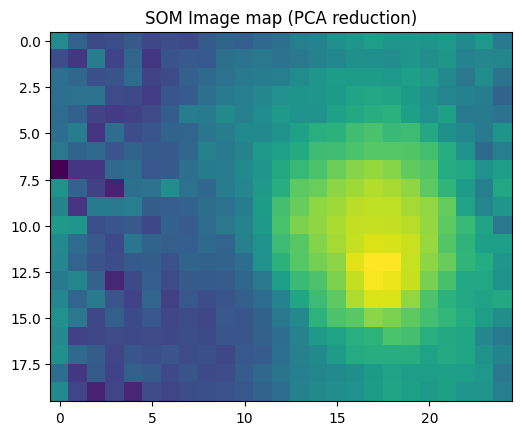

In [11]:
pca = PCA(n_components=2)
reduced_lattice = pca.fit_transform(lattice.reshape(-1, 512))
reduced_lattice = reduced_lattice.reshape(lattice.shape[0], lattice.shape[1], 2)

plt.imshow(reduced_lattice[:, :, 0], cmap='viridis')  
plt.title("SOM Image map (PCA reduction)")
plt.show()

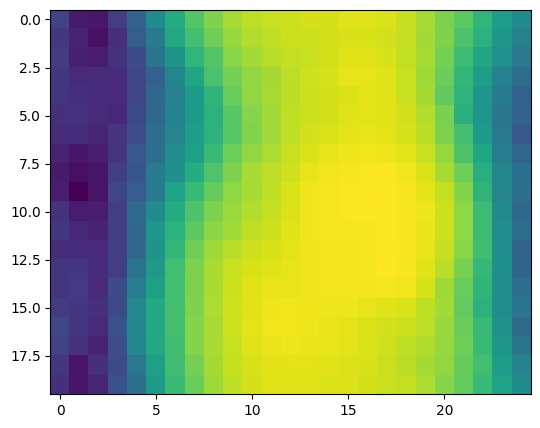

In [12]:
um = numbasom.u_matrix(lattice)
numbasom.plot_u_matrix(um, fig_size=(6.2,6.2))

In [13]:
with open(os.path.join("Pickle", "SOM_Altoroemer.pkl"), 'wb') as f:
    pickle.dump(som, f)

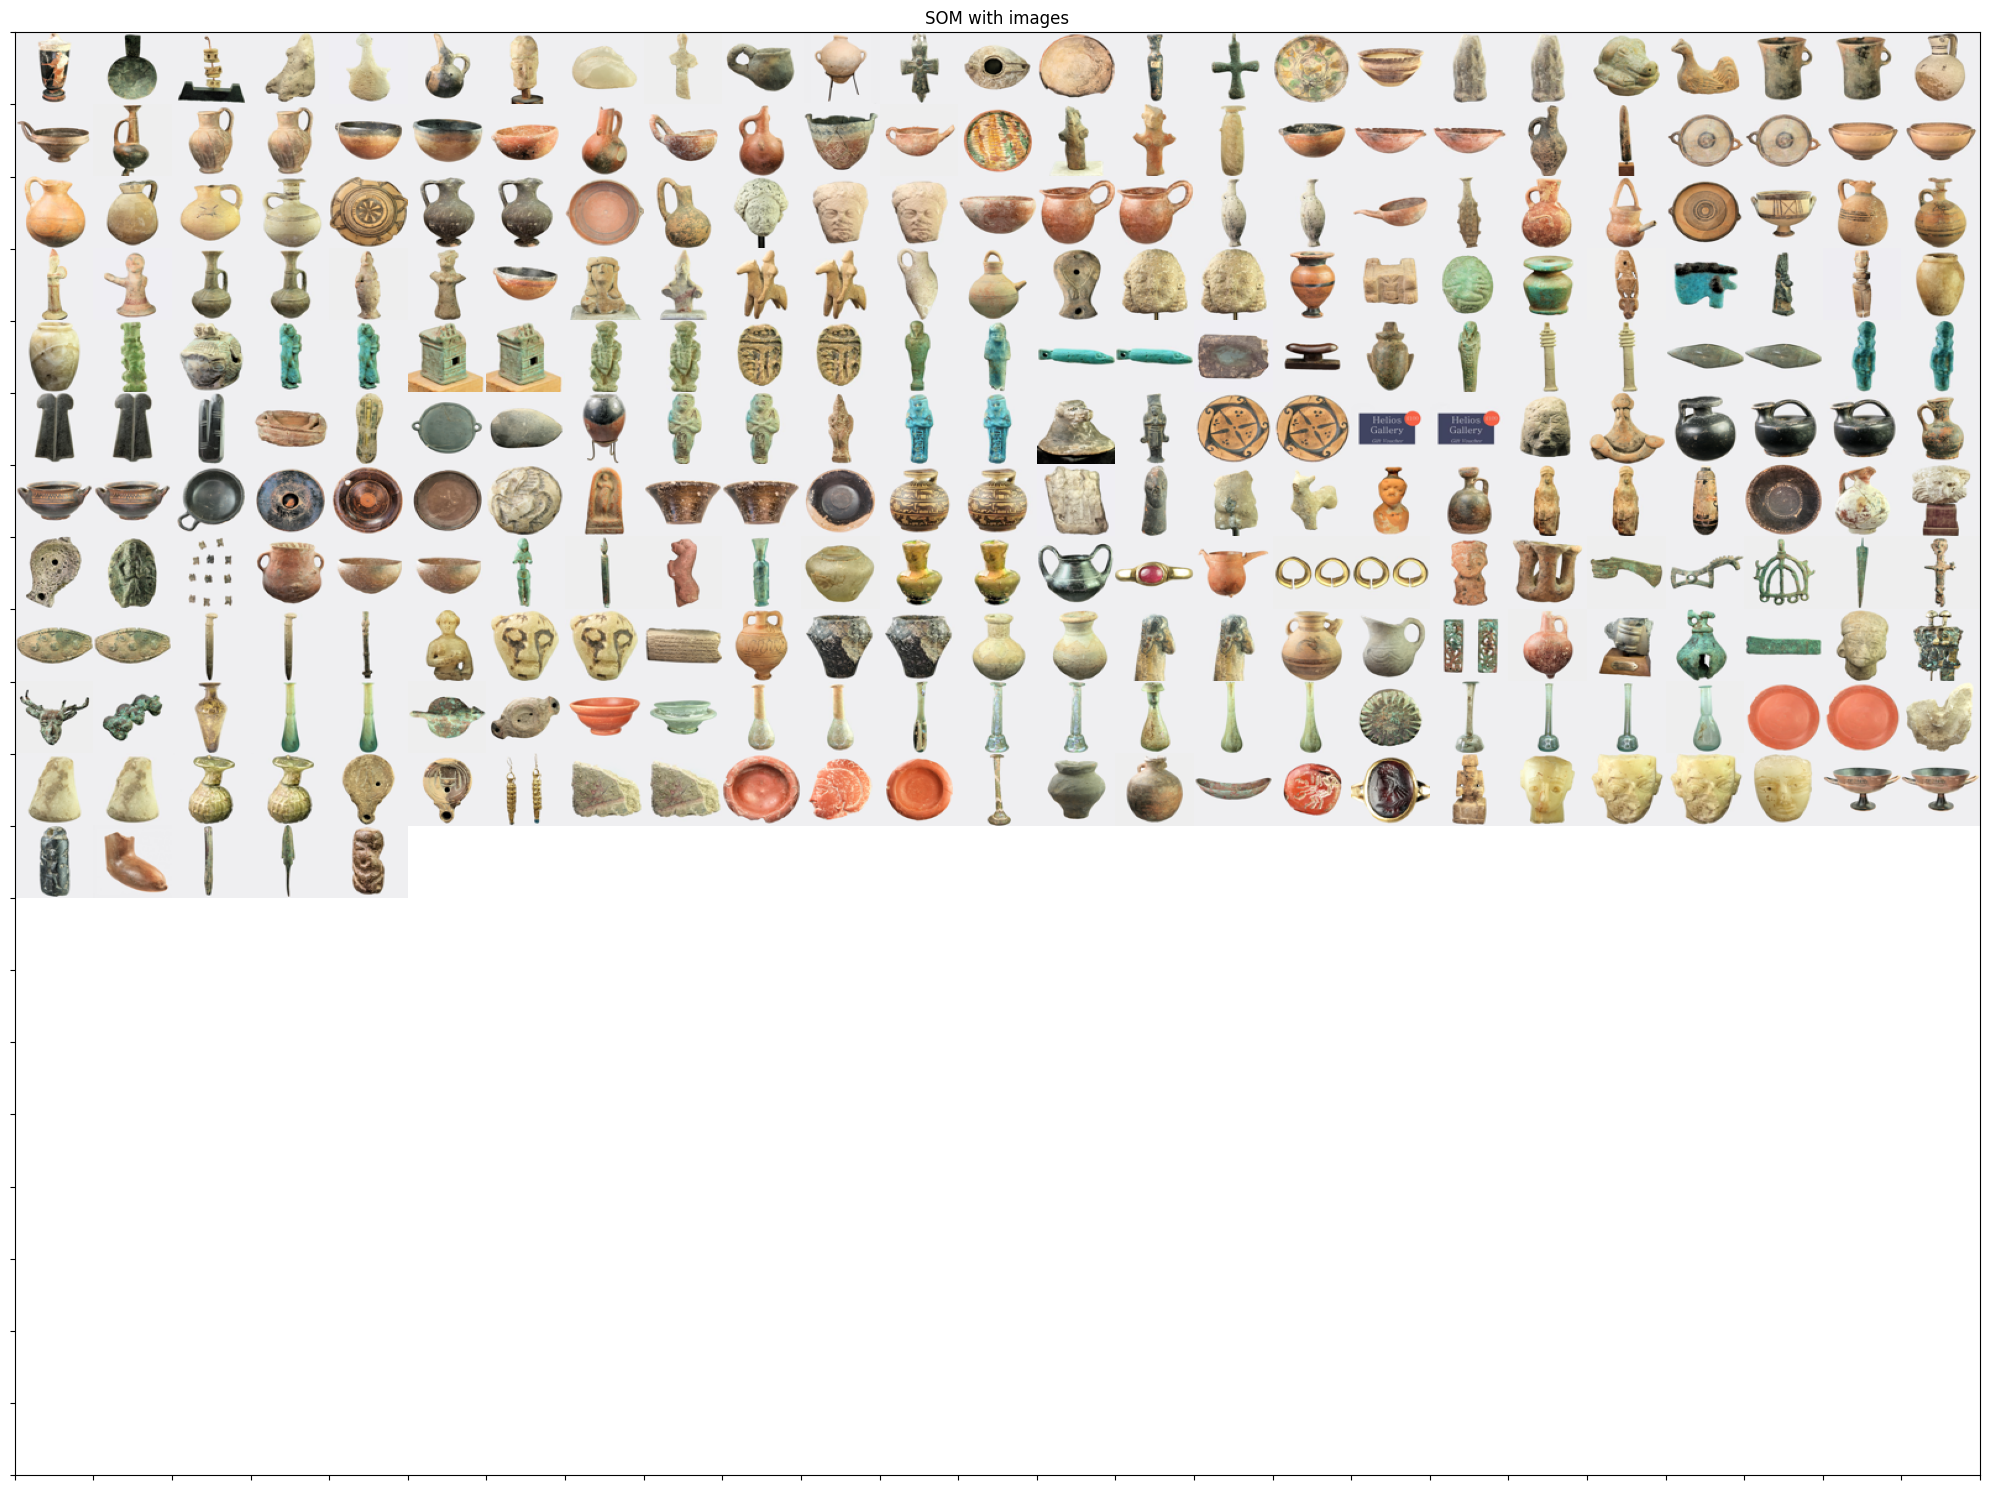

In [14]:
fig, ax = plt.subplots(figsize=(20, 15)) 

nrows, ncols = 20, 25  
image_size = (64, 64)  

resized_images = [img.resize(image_size) for img in images]

for i in range(nrows):
    for j in range(ncols):
    
        img_idx = i * ncols + j
        if img_idx < len(resized_images):  
            img = resized_images[img_idx]
          
            ax.imshow(img, extent=[j, j + 1, nrows - i - 1, nrows - i], aspect='auto')
ax.set_xlim(0, ncols)
ax.set_ylim(0, nrows)
ax.set_xticks(np.arange(0, ncols + 1, 1))
ax.set_yticks(np.arange(0, nrows + 1, 1))
ax.set_xticklabels([])
ax.set_yticklabels([])
plt.title('SOM with images')
plt.tight_layout()
plt.show()

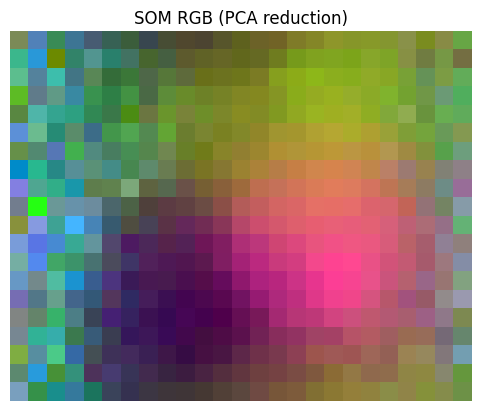

In [15]:
flat_lattice = lattice.reshape(-1, lattice.shape[-1]) 

pca = PCA(n_components=3)
pca_components = pca.fit_transform(flat_lattice) 

pca_normalized = (pca_components - pca_components.min(axis=0)) / (pca_components.max(axis=0) - pca_components.min(axis=0))

rgb_lattice = pca_normalized.reshape(lattice.shape[0], lattice.shape[1], 3)

plt.imshow(rgb_lattice)
plt.title("SOM RGB (PCA reduction)")
plt.axis("off")
plt.show()

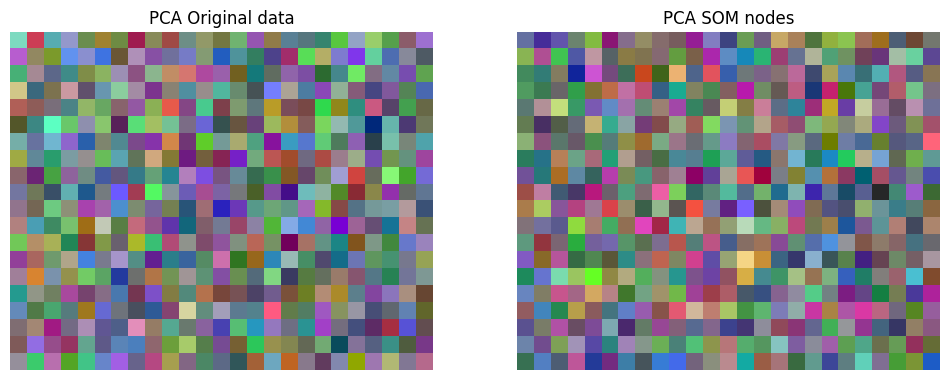

In [16]:
n_image_features = np.random.rand(500, 50) 
flat_lattice = np.random.rand(500, 50)    
lattice = (20, 25)                         

pca_full = PCA(n_components=3)
pca_full_components = pca_full.fit_transform(n_image_features)

pca_som = PCA(n_components=3)
pca_som_components = pca_som.fit_transform(flat_lattice)

pca_full_normalized = (pca_full_components - pca_full_components.min(axis=0)) / (pca_full_components.max(axis=0) - pca_full_components.min(axis=0))
pca_som_normalized = (pca_som_components - pca_som_components.min(axis=0)) / (pca_som_components.max(axis=0) - pca_som_components.min(axis=0))

n_points = lattice[0] * lattice[1]
assert pca_full_normalized.shape[0] == n_points, f"Expected {n_points} points, but got {pca_full_normalized.shape[0]}"

rgb_full = pca_full_normalized[:n_points].reshape(lattice[0], lattice[1], 3)
rgb_som = pca_som_normalized[:n_points].reshape(lattice[0], lattice[1], 3)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(rgb_full)
ax[0].set_title("PCA Original data")
ax[0].axis("off")

ax[1].imshow(rgb_som)
ax[1].set_title("PCA SOM nodes")
ax[1].axis("off")

plt.show()

In [18]:
image_paths = [os.path.join(image_folder, fname) for fname in os.listdir(image_folder) if fname.endswith(('.jpg', '.png', '.jpeg'))]

In [19]:
n_images = [preprocess_image(image_path) for image_path in image_paths]
print(f"Loaded {len(n_images)} images.")
assert len(n_images) > 0
image_features = np.random.rand(len(n_images), 128)  
assert len(image_features) == len(n_images)

Loaded 280 images.


SOM training took: 0.698494 seconds.


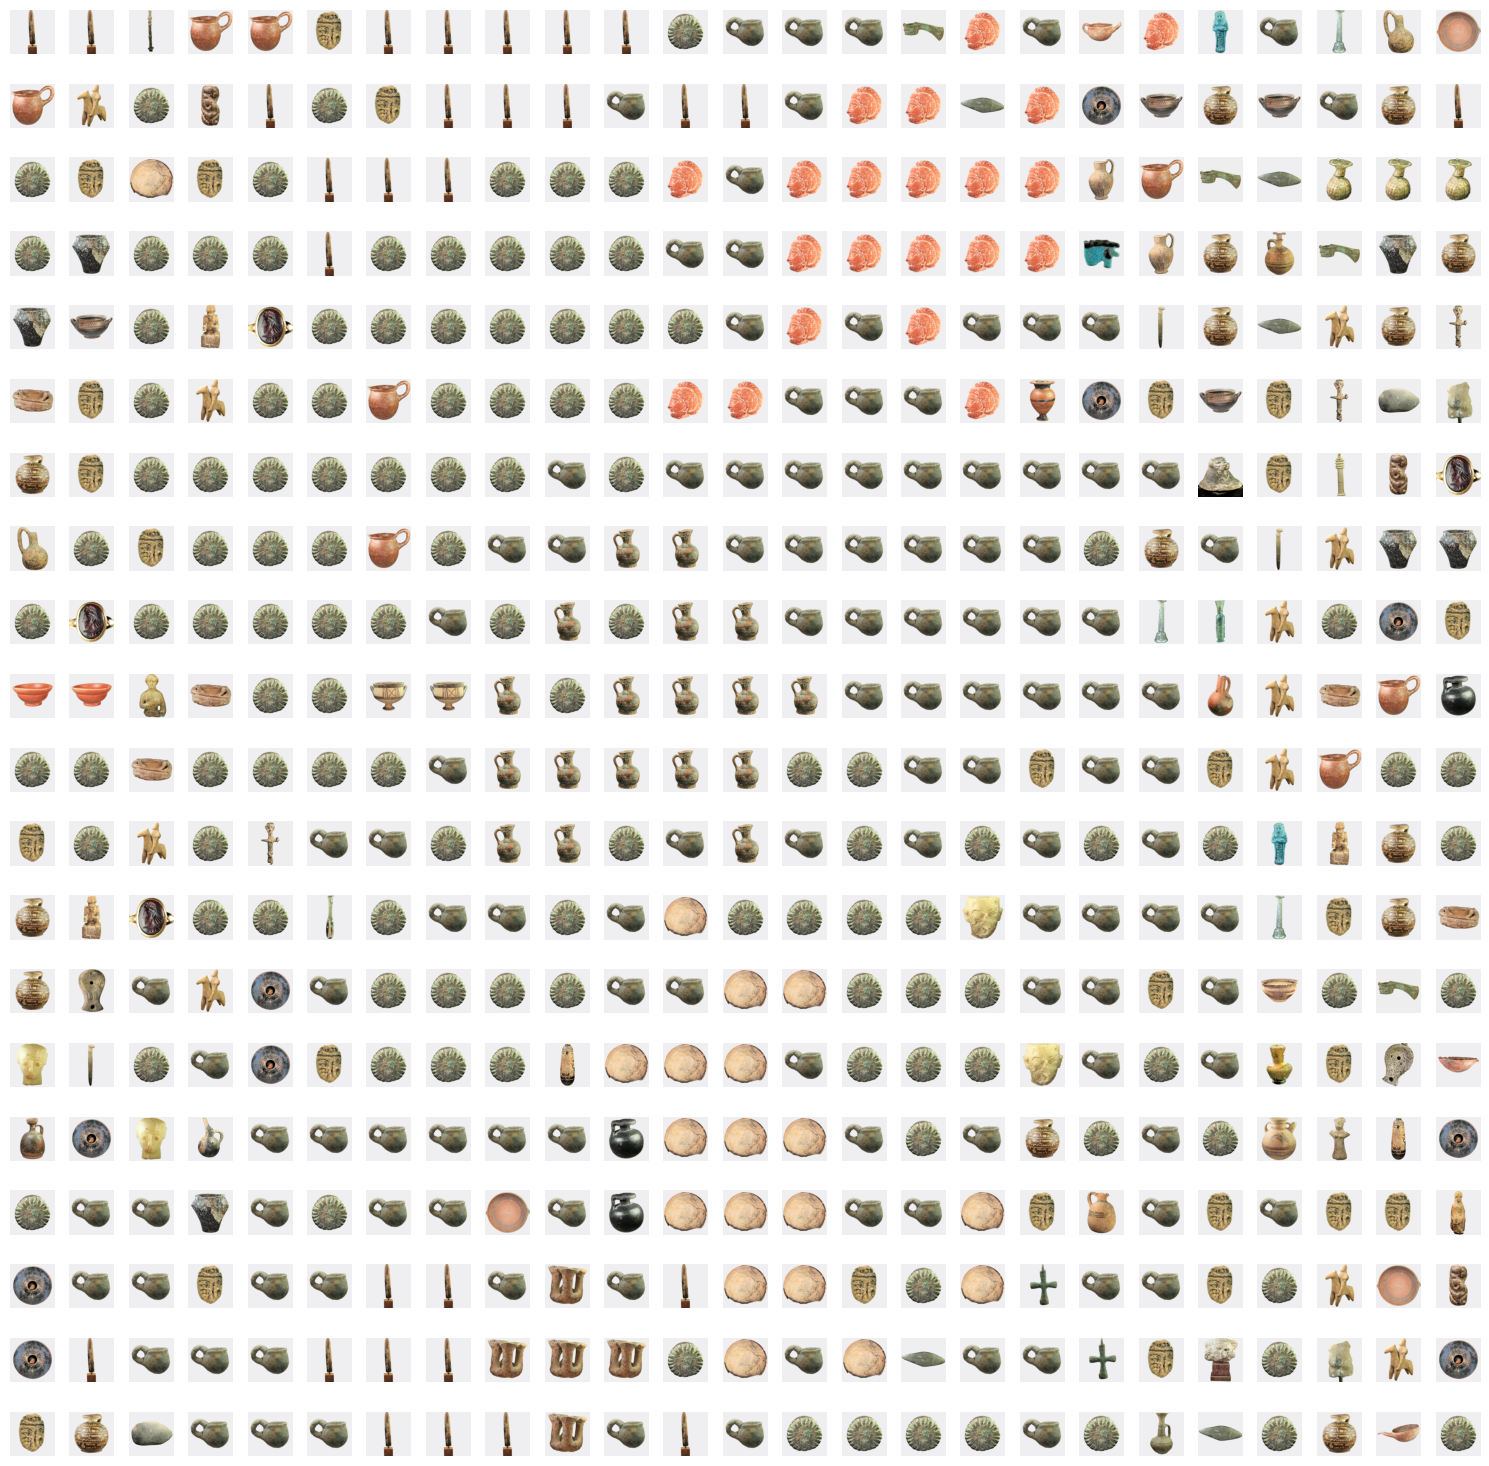

In [20]:
display_som_with_images(som, n_images, image_features)

SOM training took: 0.003972 seconds.
SOM training took: 0.003952 seconds.


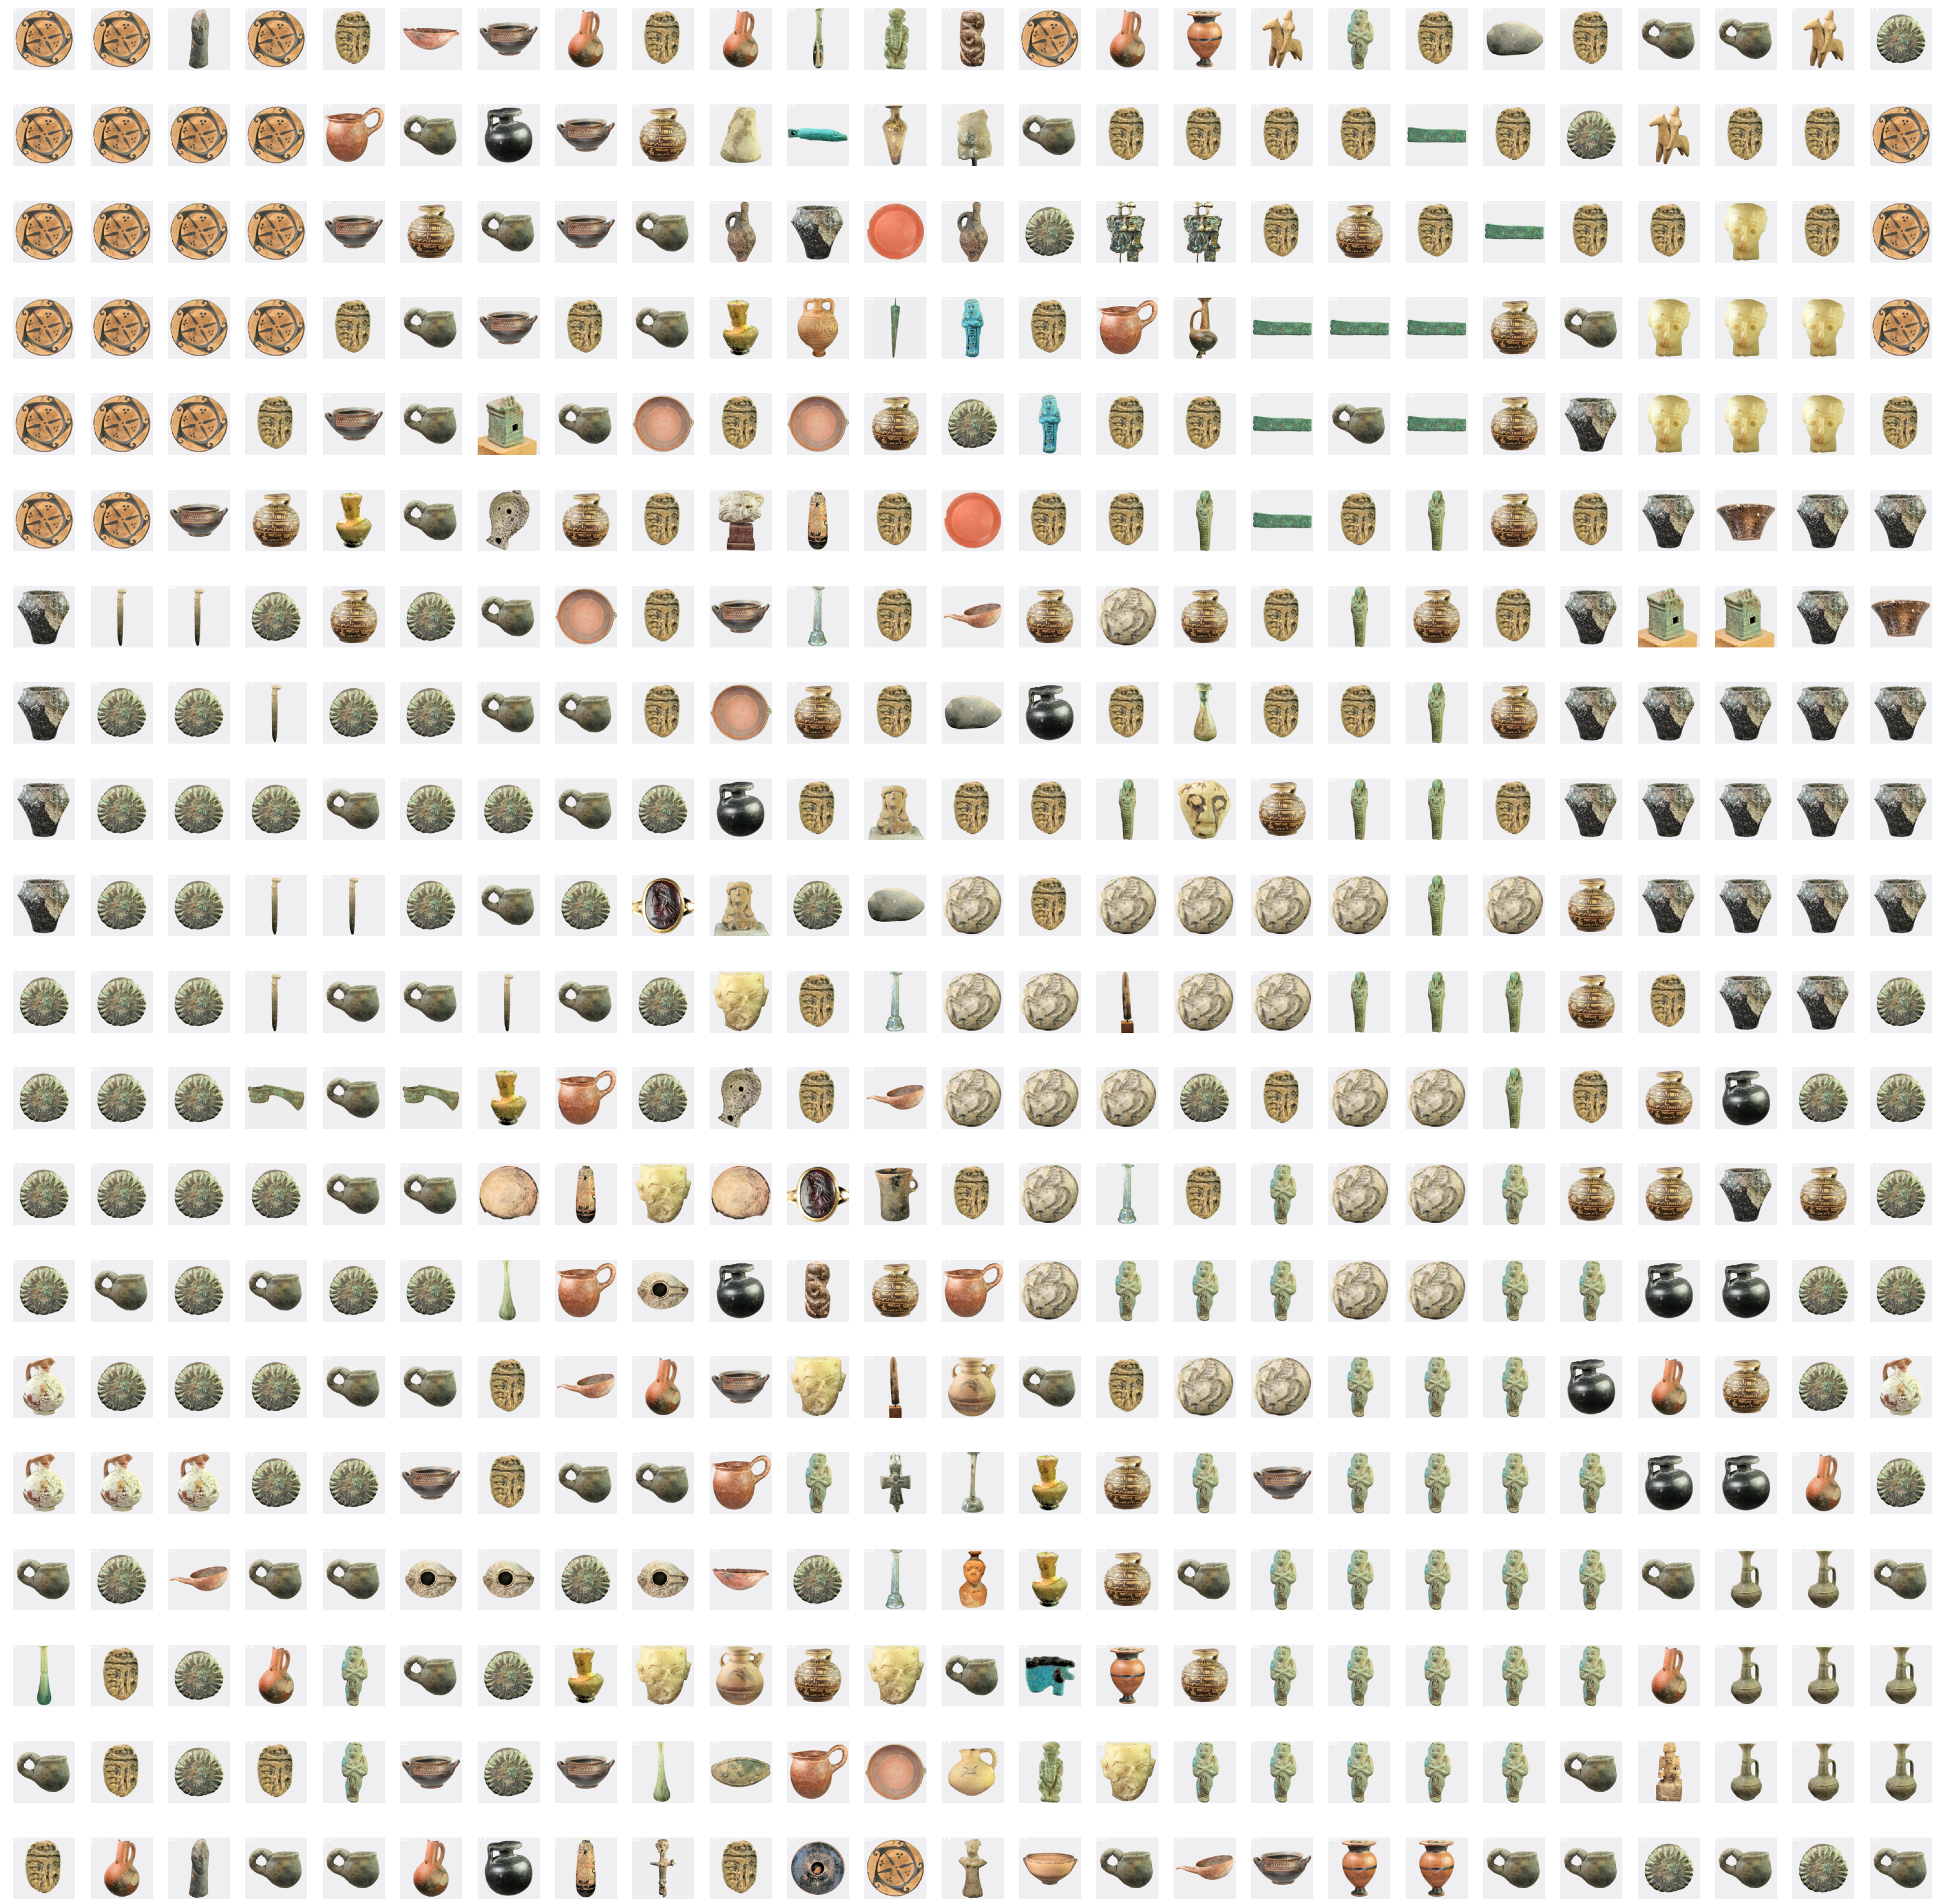

In [21]:
input_feature = np.random.rand(image_features.shape[1])  
display_som_with_activation(som, n_images, image_features, input_feature)